<a href="https://colab.research.google.com/github/aleksandrabegovic/apple_sentiment_analiza/blob/main/SentimentTesla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip -q install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
#Potrebne biblioteke za dalje analize.

In [6]:
from google.colab import files
uploaded = files.upload()
#Podaci su učitani u okruženje, nakon čega su dalje obrađeni.

Saving apple_news_data.csv to apple_news_data.csv


In [7]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.shape, df.columns
#Prikaz osnovnih informacija o datasetu, broj redova, broj kolona, kao i informacija o tome koje sve kolone postoje.

((29752, 10),
 Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
        'sentiment_polarity', 'sentiment_neg', 'sentiment_neu',
        'sentiment_pos'],
       dtype='object'))

In [8]:
df.head(5)
#Prikaz prvih 5 redova, kako bismo videli sa kojim podacima radimo.

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0,0.0,1.0,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0,0.0,1.0,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.0,0.0,1.0,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0,0.0,1.0,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0,0.0,1.0,0.0


In [9]:
df["date"] = pd.to_datetime(df["date"])
df[["date"]].head()
# Konverzija kolone 'date' u datetime format radi vremenskog
# usklađivanja finansijskih vesti sa podacima o cenama akcija.

,date
0,2024-11-27 16:39:00+00:00
1,2024-11-26 00:00:00+00:00
2,2024-11-26 00:00:00+00:00
3,2024-11-26 00:00:00+00:00
4,2024-11-26 00:00:00+00:00


In [10]:
tsla_df = df[df["symbols"].str.contains("TSLA.US", na=False)].copy()

print("Broj TSLA.US vesti:", len(tsla_df))

Broj TSLA.US vesti: 1674


In [ ]:
tsla_df.to_csv("/content/drive/MyDrive/tsla_news.csv", index=False)

In [11]:
tsla_df["year"] = pd.to_datetime(tsla_df["date"]).dt.year
tsla_df["year"].value_counts().sort_index()

,count
year,
2017,1
2020,34
2021,610
2022,480
2023,362
2024,187


In [12]:
random_news = tsla_df.sample(1)

print("DATUM:", random_news["date"].values[0])
print("NASLOV:", random_news["title"].values[0])
print("TEKST:", random_news["content"].values[0])

DATUM: 2022-06-06T16:17:52.000000000
NASLOV: Consumer Credit, Smucker Earnings, Yellen Speaks: 3 Things to Watch
TEKST: By Liz Moyer

Investing.com -- Stocks gave back some of their gains on Monday as investors tried to start the week off on a positive note, cheered by reopenings in China.

Later this week, investors will get a look at the consumer price index for May, a barometer of the economy that comes out just as the Federal Reserve is set to meet next week to make its next move on interest rates.

The expectation continues to be that the Fed will raise its benchmark rate by a half-point when it meets, and make a similar move in July. But the outlook isn't as clear on September, when the Fed could return to a more typical quarter-point move or take a pause, depending on the direction of the economic data it gets.

Analysts expect the monthly gain in CPI to be 0.7%, after 0.3% the prior month. The yearly gain is expected to be 8.3%, which is the same as the previous 12-month gain. 

In [13]:
!pip install yfinance

In [14]:
import yfinance as yf

tsla_prices = yf.download("TSLA", start="2017-01-01", end="2024-12-31")

tsla_prices = tsla_prices.reset_index()

tsla_prices = tsla_prices.rename(columns={
    "Date": "date",
    "Close": "close"
})

/tmp/ipykernel_11343/2486288263.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsla_prices = yf.download("TSLA", start="2017-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [15]:
tsla_df["date"] = pd.to_datetime(tsla_df["date"]).dt.date
tsla_prices["date"] = pd.to_datetime(tsla_prices["date"]).dt.date


tsla_df["date"] = pd.to_datetime(tsla_df["date"])
tsla_prices["date"] = pd.to_datetime(tsla_prices["date"])


tsla_df = tsla_df.sort_values("date")
tsla_prices = tsla_prices.sort_values("date")


tsla_prices.columns = tsla_prices.columns.droplevel(1)
tsla_prices = tsla_prices.rename(columns={"Close": "close"})

In [16]:
#1) priprema price tabele
tsla_prices = tsla_prices.sort_values("date").copy()

tsla_prices["close_t"] = tsla_prices["close"]
tsla_prices["close_t1"] = tsla_prices["close"].shift(-1)
tsla_prices["close_t2"] = tsla_prices["close"].shift(-2)
tsla_prices["close_t3"] = tsla_prices["close"].shift(-3)

tsla_prices["open_t1"] = tsla_prices["Open"].shift(-1)
tsla_prices["open_t2"] = tsla_prices["Open"].shift(-2)

tsla_prices["high_t1"] = tsla_prices["High"].shift(-1)
tsla_prices["high_t2"] = tsla_prices["High"].shift(-2)
tsla_prices["high_t3"] = tsla_prices["High"].shift(-3)

tsla_prices["low_t1"] = tsla_prices["Low"].shift(-1)
tsla_prices["low_t2"] = tsla_prices["Low"].shift(-2)
tsla_prices["low_t3"] = tsla_prices["Low"].shift(-3)

tsla_prices["avg_t"] = (
tsla_prices["Open"] +
tsla_prices["High"] +
tsla_prices["Low"] +
tsla_prices["close"]
) / 4

tsla_prices["avg_t1"] = tsla_prices["avg_t"].shift(-1)

#2) merge vesti, sledeći trading dan
tsla_merged = pd.merge_asof(
tsla_df.sort_values("date"),
tsla_prices[[
"date",
"close_t", "close_t1", "close_t2", "close_t3",
"open_t1", "open_t2",
"high_t1", "high_t2", "high_t3",
"low_t1", "low_t2", "low_t3",
"avg_t", "avg_t1"
]],
on="date",
direction="forward"
)

#3) osnovni prinosi
tsla_merged["return_close_close"] = (
tsla_merged["close_t1"] - tsla_merged["close_t"]
) / tsla_merged["close_t"]

tsla_merged["return_open_close"] = (
tsla_merged["close_t1"] - tsla_merged["open_t1"]
) / tsla_merged["open_t1"]

tsla_merged["return_open_open"] = (
tsla_merged["open_t2"] - tsla_merged["open_t1"]
) / tsla_merged["open_t1"]

tsla_merged["return_avg_avg"] = (
tsla_merged["avg_t1"] - tsla_merged["avg_t"]
) / tsla_merged["avg_t"]

#4) dodatni prinosi za 2 i 3 dana
tsla_merged["return_2d"] = (
tsla_merged["close_t2"] - tsla_merged["close_t"]
) / tsla_merged["close_t"]

tsla_merged["return_3d"] = (
tsla_merged["close_t3"] - tsla_merged["close_t"]
) / tsla_merged["close_t"]

#5) targeti za neuronsku mrežu
tsla_merged["y_1d"] = (tsla_merged["return_close_close"] > 0).astype(int)
tsla_merged["y_2d"] = (tsla_merged["return_2d"] > 0).astype(int)
tsla_merged["y_3d"] = (tsla_merged["return_3d"] > 0).astype(int)

#6)
tsla_merged["max_high_3d"] = tsla_merged[["high_t1", "high_t2", "high_t3"]].max(axis=1)
tsla_merged["min_low_3d"] = tsla_merged[["low_t1", "low_t2", "low_t3"]].min(axis=1)

tsla_merged["up_move_3d"] = tsla_merged["max_high_3d"] - tsla_merged["close_t"]
tsla_merged["down_move_3d"] = tsla_merged["min_low_3d"] - tsla_merged["close_t"]

tsla_merged["y_prof_3d"] = (
abs(tsla_merged["up_move_3d"]) > abs(tsla_merged["down_move_3d"])
).astype(int)

tsla_merged["return_prof_3d"] = (
abs(tsla_merged["max_high_3d"] - tsla_merged["close_t"]) -
abs(tsla_merged["min_low_3d"] - tsla_merged["close_t"])
) / tsla_merged["close_t"]

#7) kompanija
tsla_merged["company"] = "TSLA"

#8) čišćenje
tsla_merged = tsla_merged.dropna(subset=[
"return_close_close", "return_2d", "return_3d",
"max_high_3d", "min_low_3d"
])

In [17]:
tsla_merged[["date", "title", "close_t", "close_t1", "return_close_close","return_open_open","return_open_close","return_avg_avg"]].head()

,date,title,close_t,close_t1,return_close_close,return_open_open,return_open_close,return_avg_avg
0,2017-10-05,New Research: Key Drivers of Growth for Micros...,23.688667,23.792000,0.004362,-0.009771,0.010705,0.001556
1,2020-04-09,The Top 3 Ways to Trade a Pullback in Volatility,38.200001,43.396667,0.136038,0.184374,0.103006,0.090968
2,2020-05-06,Crazy Trading on China's Nasdaq Has Its Own Logic,52.172001,52.002666,-0.003246,0.021307,0.003641,0.005148
3,2020-07-02,7 Risky Penny Stocks (That Could Really Pay Off),80.577332,91.438667,0.134794,0.100510,0.074325,0.092565
4,2020-07-30,"Computing is the new horsepower, carmaker Audi...",99.166000,95.384003,-0.038138,-0.043432,-0.055604,-0.012742


In [18]:
d = pd.to_datetime("2021-07-28")

tsla_merged[tsla_merged["date"].dt.date == d.date()][["close_t","close_t1"]].drop_duplicates()

,close_t,close_t1
464,215.660004,225.78334


In [19]:
tsla_merged["direction_close_close"] = tsla_merged["return_close_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

tsla_merged["direction_open_open"] = tsla_merged["return_open_open"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

tsla_merged["direction_open_close"] = tsla_merged["return_open_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

tsla_merged["direction_avg_avg"] = tsla_merged["return_avg_avg"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

In [20]:
tsla_merged["direction_close_close"].value_counts()

,count
direction_close_close,
DOWN,847
UP,827


In [21]:
tsla_merged["direction_open_open"].value_counts()

,count
direction_open_open,
DOWN,888
UP,786


In [22]:
tsla_merged["direction_open_close"].value_counts()

,count
direction_open_close,
DOWN,903
UP,771


In [23]:
tsla_merged["direction_avg_avg"].value_counts()

,count
direction_avg_avg,
DOWN,891
UP,783


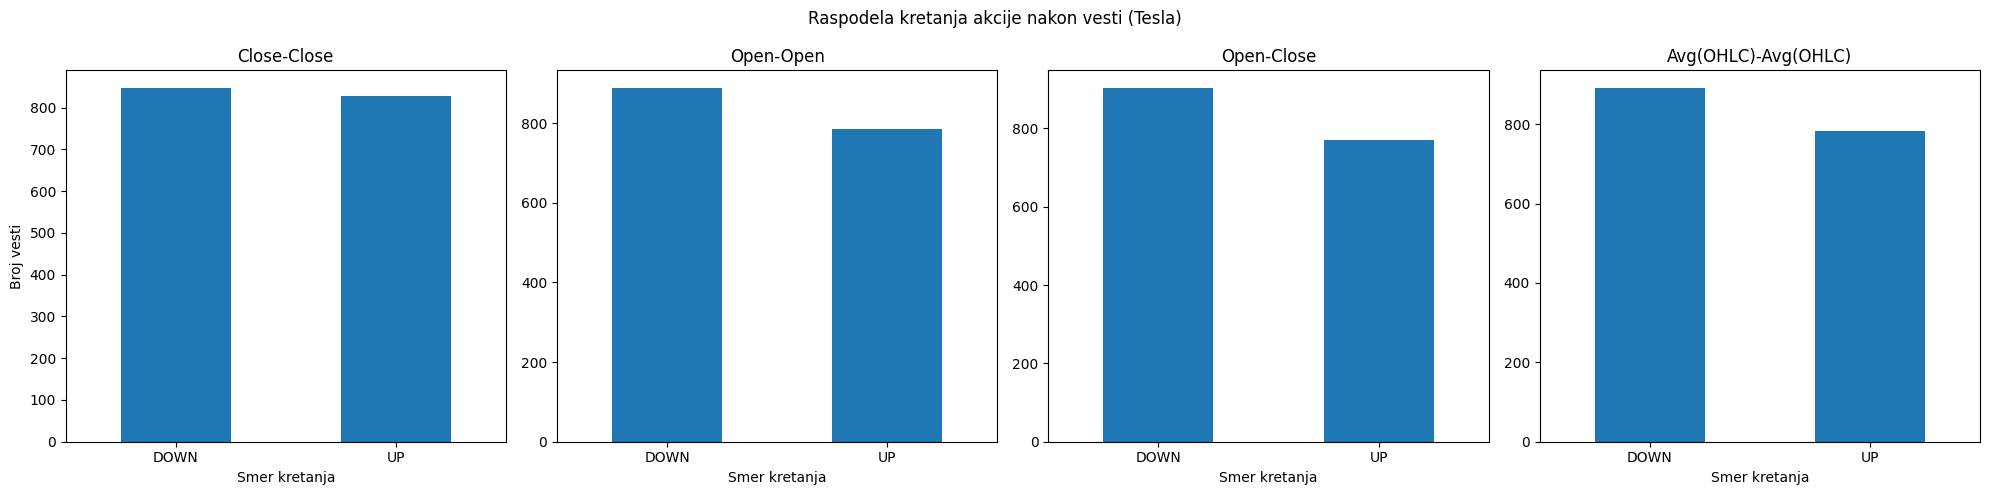

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# close-close
tsla_merged["direction_close_close"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Close-Close")
axes[0].set_xlabel("Smer kretanja")
axes[0].set_ylabel("Broj vesti")
axes[0].tick_params(axis='x', rotation=0)

# open-open
tsla_merged["direction_open_open"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Open-Open")
axes[1].set_xlabel("Smer kretanja")
axes[1].tick_params(axis='x', rotation=0)

# open-close
tsla_merged["direction_open_close"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Open-Close")
axes[2].set_xlabel("Smer kretanja")
axes[2].tick_params(axis='x', rotation=0)

# avg-avg
tsla_merged["direction_avg_avg"].value_counts().plot(
    kind="bar", ax=axes[3]
)
axes[3].set_title("Avg(OHLC)-Avg(OHLC)")
axes[3].set_xlabel("Smer kretanja")
axes[3].tick_params(axis='x', rotation=0)

plt.suptitle("Raspodela kretanja akcije nakon vesti (Tesla)")

plt.tight_layout()
plt.show()

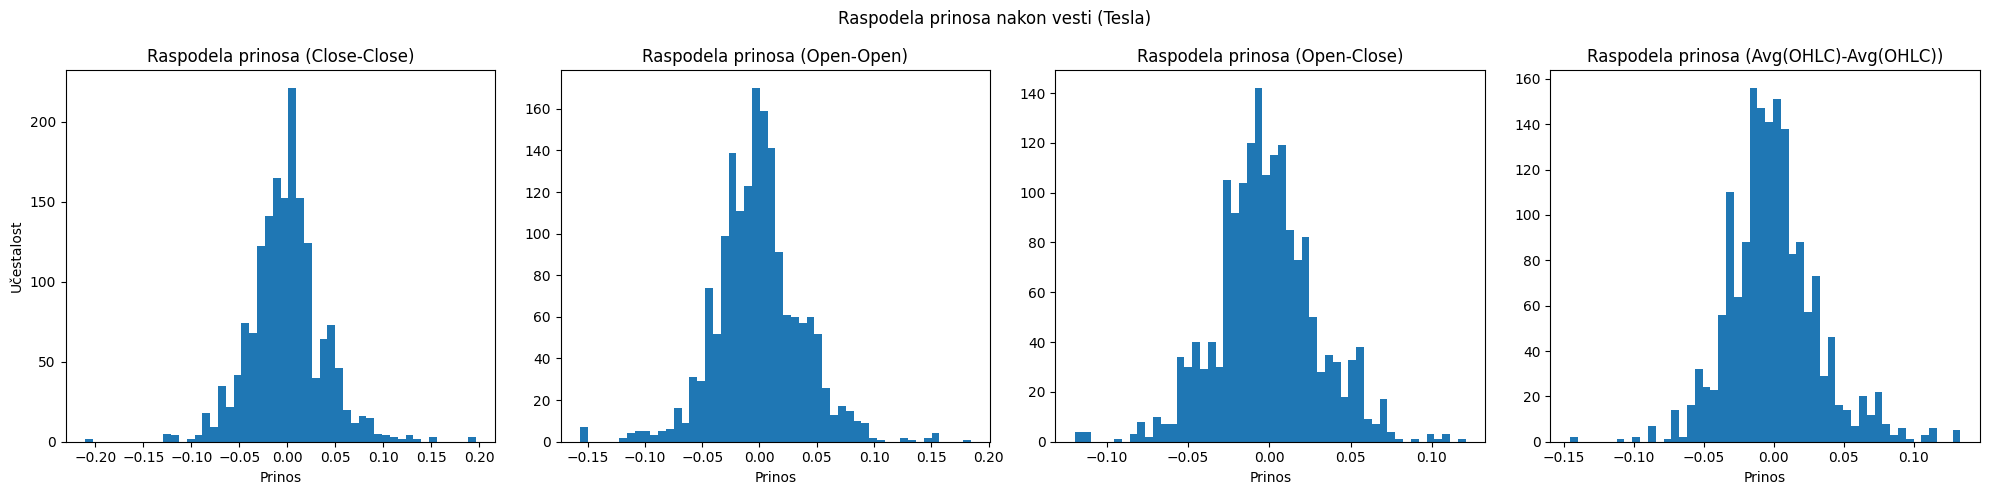

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# Close-Close
axes[0].hist(tsla_merged["return_close_close"].dropna(), bins=50)
axes[0].set_title("Raspodela prinosa (Close-Close)")
axes[0].set_xlabel("Prinos")
axes[0].set_ylabel("Učestalost")

# Open-Open
axes[1].hist(tsla_merged["return_open_open"].dropna(), bins=50)
axes[1].set_title("Raspodela prinosa (Open-Open)")
axes[1].set_xlabel("Prinos")

# Open-Close
axes[2].hist(tsla_merged["return_open_close"].dropna(), bins=50)
axes[2].set_title("Raspodela prinosa (Open-Close)")
axes[2].set_xlabel("Prinos")

# Avg-Avg
axes[3].hist(tsla_merged["return_avg_avg"].dropna(), bins=50)
axes[3].set_title("Raspodela prinosa (Avg(OHLC)-Avg(OHLC))")
axes[3].set_xlabel("Prinos")

plt.suptitle("Raspodela prinosa nakon vesti (Tesla)")

plt.tight_layout()
plt.show()

In [25]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [ ]:
from typing import Optional
from enum import Enum
from pydantic import BaseModel, Field


class Sentiment(str, Enum):
    NEGATIVE = "negative"
    NEUTRAL = "neutral"
    POSITIVE = "positive"


class Topic(str, Enum):
    EV_PRODUCTION = "ev_production_deliveries"
    AUTOPILOT = "autopilot_full_self_driving"
    ENERGY = "energy_storage_solar"
    AI = "ai_ml_robotics"
    FINANCIALS = "earnings_revenue_profit"
    COMPETITION = "competition_ev_market"
    REGULATION = "regulation_government_policy"
    LEGAL = "legal_lawsuit"
    SUPPLY_CHAIN = "supply_chain_production"
    MACRO = "macro_economy_rates_inflation"
    MERGERS = "mna_partnerships"
    OTHER = "other"


class NewsAnnotation(BaseModel):
    """Structured annotation for Tesla-related financial news."""

    sentiment: Optional[Sentiment] = Field(
        default=None,
        description="Overall sentiment expressed toward Tesla in the news.",
        examples=[Sentiment.NEGATIVE]
    )

    sentiment_score: Optional[float] = Field(
        default=None,
        description="Sentiment score between -1 and 1 where -1 is very negative, 0 neutral, and 1 very positive.",
        examples=[-0.8, 0.0, 0.7]
    )

    topic: Optional[Topic] = Field(
        default=None,
        description="Main topic of the news related to Tesla. Choose the closest single category.",
        examples=[Topic.EV_PRODUCTION]
    )

In [ ]:
import pandas as pd

# funkcija za spajanje title i content
def combine_title_content(row, max_chars=2000):
    title = str(row.get("title", "") or "").strip()
    content = str(row.get("content", "") or "").strip()

    if len(content) > max_chars:
        content = content[:max_chars]

    if content:
        return f"TITLE: {title}\nCONTENT: {content}"

    return f"TITLE: {title}"


tsla_merged["text_for_ie"] = tsla_merged.apply(combine_title_content, axis=1)

tsla_merged[["text_for_ie"]].head(2)

,text_for_ie
0,TITLE: New Research: Key Drivers of Growth for...
1,TITLE: The Top 3 Ways to Trade a Pullback in V...


In [26]:
!pip -q install openai langchain langchain-openai pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 13.2 MB/s eta 0:00:00


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

system_msg = """
You are an expert financial information extraction agent.
Determine Tesla-targeted sentiment based on the impact on Tesla, Inc. (Tesla, TSLA, Elon Musk company).

Return:
- sentiment: EXACTLY one of (positive, neutral, negative)
- sentiment_score: a number between -1 and 1

Rules for sentiment_score:
- -1 = extremely negative news for Tesla
- 0 = neutral impact
- 1 = extremely positive news
- intermediate values allowed (e.g., -0.3, 0.6)

The sentiment_score must be consistent with the sentiment label.

If Tesla is mentioned but the impact is unclear, return neutral and sentiment_score = 0.
Return null ONLY if Tesla is not mentioned at all.
Use lowercase only.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_msg),
    ("human", "Analyze the following Tesla-related news:\n{text}")
])

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

ie_chain = prompt | llm.with_structured_output(NewsAnnotation)

In [ ]:
from time import sleep
import pandas as pd

def tag_df_openai(
    df: pd.DataFrame,
    text_col="text_for_ie",
    sleep_sec=0.4,
    save_every=100,
    save_path=None
):
    """
    Automatska anotacija finansijskih vesti pomoću LLM modela
    za Tesla kompaniju.
    """

    out = df.copy()
    sentiments, scores, topics = [], [], []

    for i, txt in enumerate(out[text_col], start=1):
        try:
            res = ie_chain.invoke({"text": txt})

            sentiments.append(res.sentiment.value if res.sentiment else None)
            scores.append(res.sentiment_score if res.sentiment_score is not None else None)
            topics.append(res.topic.value if res.topic else None)

        except Exception:
            sentiments.append(None)
            scores.append(None)
            topics.append(None)

        if i % 50 == 0:
            print(f"Processed {i} rows")

        if save_path and i % save_every == 0:
            out.loc[:i-1, "sentiment"] = sentiments
            out.loc[:i-1, "sentiment_score"] = scores
            out.loc[:i-1, "topic"] = topics
            out.to_csv(save_path, index=False)

        sleep(sleep_sec)

    out["sentiment"] = sentiments
    out["sentiment_score"] = scores
    out["topic"] = topics

    # FINALNO ČUVANJE
    if save_path:
        out.to_csv(save_path, index=False)
        print(f"Final save completed: {save_path}")

    return out

In [ ]:
tsla_tagged = tag_df_openai(
    tsla_merged,
    text_col="text_for_ie",
    save_path="/content/drive/MyDrive/tsla_news_tagged.csv"
)

Processed 50 rows
Processed 100 rows
Processed 150 rows
Processed 200 rows
Processed 250 rows
Processed 300 rows
Processed 350 rows
Processed 400 rows
Processed 450 rows
Processed 500 rows
Processed 550 rows
Processed 600 rows
Processed 650 rows
Processed 700 rows
Processed 750 rows
Processed 800 rows
Processed 850 rows
Processed 900 rows
Processed 950 rows
Processed 1000 rows
Processed 1050 rows
Processed 1100 rows
Processed 1150 rows
Processed 1200 rows
Processed 1250 rows
Processed 1300 rows
Processed 1350 rows
Processed 1400 rows
Processed 1450 rows
Processed 1500 rows
Processed 1550 rows
Processed 1600 rows
Processed 1650 rows
Final save completed: /content/drive/MyDrive/tsla_news_tagged.csv


In [27]:
import pandas as pd

tsla_tagged = pd.read_csv("/content/drive/MyDrive/tsla_news_tagged.csv")

In [28]:
tsla_tagged.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'open_t1', 'open_t2', 'avg_t', 'avg_t1',
       'return_close_close', 'return_open_close', 'return_open_open',
       'return_avg_avg', 'direction_close_close', 'direction_open_open',
       'direction_open_close', 'direction_avg_avg', 'text_for_ie', 'sentiment',
       'sentiment_score', 'topic'],
      dtype='object')

In [29]:
tsla_tagged[["date", "title", "sentiment", "sentiment_score", "topic"]].head(10)

,date,title,sentiment,sentiment_score,topic
0,2017-10-05,New Research: Key Drivers of Growth for Micros...,neutral,0.0,other
1,2020-04-09,The Top 3 Ways to Trade a Pullback in Volatility,neutral,0.0,macro_economy_rates_inflation
2,2020-05-06,Crazy Trading on China's Nasdaq Has Its Own Logic,neutral,0.0,other
3,2020-07-02,7 Risky Penny Stocks (That Could Really Pay Off),neutral,0.0,other
4,2020-07-30,"Computing is the new horsepower, carmaker Audi...",negative,-0.6,competition_ev_market
5,2020-07-30,"Computing is the new horsepower, carmaker Audi...",negative,-0.6,competition_ev_market
6,2020-08-25,FANGMAN Is No Match for These 'Seven Princesses',neutral,0.0,other
7,2020-08-25,FANGMAN Is No Match for These 'Seven Princesses',neutral,0.0,other
8,2020-08-28,'This is a liquidity driven rally': Zor Capita...,neutral,0.0,macro_economy_rates_inflation
9,2020-08-31,You Think FAANG Is Distorting the S&amp;P? Con...,neutral,0.0,other


In [30]:
tsla_tagged["sentiment"].value_counts()

,count
sentiment,
neutral,978
positive,364
negative,332


In [31]:
tsla_tagged["sentiment_score"].describe()

,sentiment_score
count,1674.000000
mean,0.036141
std,0.412987
min,-0.800000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.900000


In [32]:
tsla_tagged[["sentiment","sentiment_score"]].head(20)

,sentiment,sentiment_score
0,neutral,0.0
1,neutral,0.0
2,neutral,0.0
3,neutral,0.0
4,negative,-0.6
5,negative,-0.6
6,neutral,0.0
7,neutral,0.0
8,neutral,0.0
9,neutral,0.0


In [33]:
tsla_tagged["date_only"] = pd.to_datetime(tsla_tagged["date"]).dt.date

In [34]:
sent_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

tsla_tagged["sentiment_num"] = tsla_tagged["sentiment"].map(sent_map)

In [ ]:
daily_sentiment_class = tsla_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    news_count=("sentiment_num", "count")
).reset_index()

In [ ]:
daily_sentiment_class.head(20)

,date_only,daily_sentiment_class,news_count
0,2017-10-05,0.000000,1
1,2020-04-09,0.000000,1
2,2020-05-06,0.000000,1
3,2020-07-02,0.000000,1
4,2020-07-30,-1.000000,2
5,2020-08-25,0.000000,2
6,2020-08-28,0.000000,1
7,2020-08-31,0.000000,2
8,2020-09-03,-1.000000,1
9,2020-09-04,0.000000,2


In [ ]:
daily_sentiment_score = tsla_tagged.groupby("date_only").agg(
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("sentiment_score", "count")
).reset_index()

In [ ]:
daily_sentiment_score.head(20)

,date_only,daily_sentiment_score,news_count
0,2017-10-05,0.00,1
1,2020-04-09,0.00,1
2,2020-05-06,0.00,1
3,2020-07-02,0.00,1
4,2020-07-30,-0.60,2
5,2020-08-25,0.00,2
6,2020-08-28,0.00,1
7,2020-08-31,0.00,2
8,2020-09-03,-0.70,1
9,2020-09-04,0.00,2


In [ ]:
daily_sentiment = tsla_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("title", "count"),
    return_close_close=("return_close_close", "first"),
    return_open_close=("return_open_close", "first"),
    return_open_open=("return_open_open", "first"),
    return_avg_avg=("return_avg_avg", "first")
).reset_index()

In [ ]:
d = pd.to_datetime("2023-11-03").date()

daily_sentiment[daily_sentiment["date_only"] == d]

,date_only,daily_sentiment_class,daily_sentiment_score,news_count,return_close_close,return_open_close,return_open_open,return_avg_avg
625,2023-11-03,-0.333333,-0.233333,3,-0.003137,-0.021029,-0.017859,-0.001479


In [ ]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
))[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

/tmp/ipykernel_14609/172947486.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sentiment.groupby(pd.cut(


,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_score,,,,
negative,0.002249,0.002749,0.003792,-0.002505
neutral,0.000595,-0.000350,0.000389,0.000914
positive,-0.004142,-0.005381,-0.004789,0.000025


In [ ]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_class,,,,
negative,-0.001902,0.002161,0.004112,-0.004656
neutral,0.000739,-0.000441,0.000209,0.001105
positive,-0.004814,-0.005847,-0.004953,-0.000453


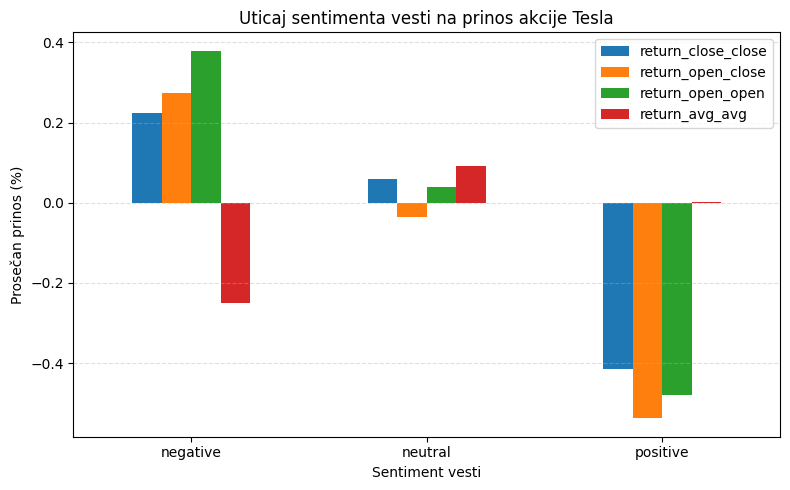

In [ ]:
import matplotlib.pyplot as plt

returns_by_sentiment = daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

# u procente
returns_by_sentiment_percent = returns_by_sentiment * 100

# plot
returns_by_sentiment_percent.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Uticaj sentimenta vesti na prinos akcije Tesla")
plt.xlabel("Sentiment vesti")
plt.ylabel("Prosečan prinos (%)")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

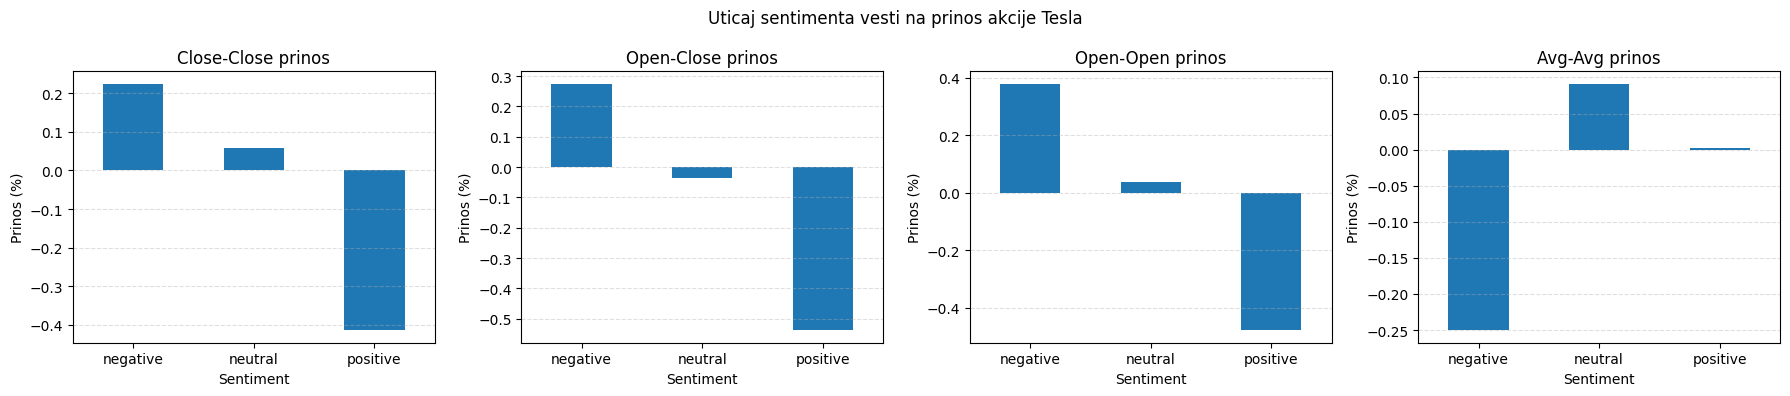

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

# Close-Close
returns_by_sentiment_percent["return_close_close"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Close-Close prinos")

# Open-Close
returns_by_sentiment_percent["return_open_close"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Open-Close prinos")

# Open-Open
returns_by_sentiment_percent["return_open_open"].plot(kind="bar", ax=axes[2])
axes[2].set_title("Open-Open prinos")

# Avg-Avg
returns_by_sentiment_percent["return_avg_avg"].plot(kind="bar", ax=axes[3])
axes[3].set_title("Avg-Avg prinos")

for ax in axes:
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Prinos (%)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Uticaj sentimenta vesti na prinos akcije Tesla")

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

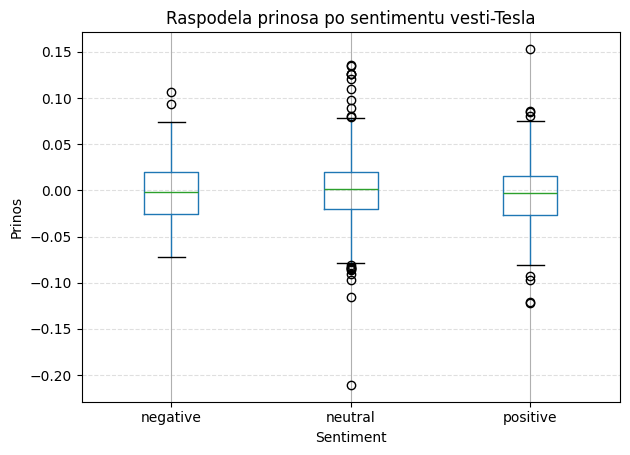

In [ ]:
import matplotlib.pyplot as plt

# kopija podataka
df_daily = daily_sentiment.copy()

# formiranje grupa na osnovu daily_sentiment_class
df_daily["sentiment_group"] = pd.cut(
    df_daily["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
)

# boxplot
plt.figure(figsize=(6,4))

df_daily.boxplot(
    column="return_close_close",
    by="sentiment_group"
)

plt.title("Raspodela prinosa po sentimentu vesti-Tesla")
plt.suptitle("")  # uklanja default naslov
plt.xlabel("Sentiment")
plt.ylabel("Prinos")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

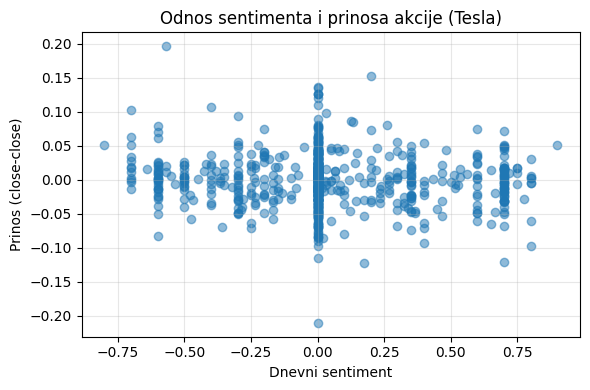

In [ ]:
import matplotlib.pyplot as plt

# uklonjeno NaN
df_daily = daily_sentiment.dropna(subset=["daily_sentiment_score", "return_close_close"])

plt.figure(figsize=(6,4))

plt.scatter(
    df_daily["daily_sentiment_score"],
    df_daily["return_close_close"],
    alpha=0.5
)

plt.title("Odnos sentimenta i prinosa akcije (Tesla)")
plt.xlabel("Dnevni sentiment")
plt.ylabel("Prinos (close-close)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
print(len(tsla_merged))
print(len(tsla_tagged))

tsla_merged[["date", "title"]].head()
tsla_tagged[["date", "title", "sentiment", "sentiment_score"]].head()


1674
1674


,date,title,sentiment,sentiment_score
0,2017-10-05,New Research: Key Drivers of Growth for Micros...,neutral,0.0
1,2020-04-09,The Top 3 Ways to Trade a Pullback in Volatility,neutral,0.0
2,2020-05-06,Crazy Trading on China's Nasdaq Has Its Own Logic,neutral,0.0
3,2020-07-02,7 Risky Penny Stocks (That Could Really Pay Off),neutral,0.0
4,2020-07-30,"Computing is the new horsepower, carmaker Audi...",negative,-0.6


In [36]:
tsla_final = tsla_merged.copy()

tsla_final["sentiment"] = tsla_tagged["sentiment"].values
tsla_final["sentiment_score"] = tsla_tagged["sentiment_score"].values
tsla_final["topic"] = tsla_tagged["topic"].values
tsla_final["sentiment_num"] = tsla_tagged["sentiment_num"].values

In [37]:
tsla_final["return_prof_3d"] = (
    abs(tsla_final["max_high_3d"] - tsla_final["close_t"]) -
    abs(tsla_final["min_low_3d"] - tsla_final["close_t"])
) / tsla_final["close_t"]

In [38]:
tsla_final.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'close_t2', 'close_t3', 'open_t1',
       'open_t2', 'high_t1', 'high_t2', 'high_t3', 'low_t1', 'low_t2',
       'low_t3', 'avg_t', 'avg_t1', 'return_close_close', 'return_open_close',
       'return_open_open', 'return_avg_avg', 'return_2d', 'return_3d', 'y_1d',
       'y_2d', 'y_3d', 'max_high_3d', 'min_low_3d', 'up_move_3d',
       'down_move_3d', 'y_prof_3d', 'return_prof_3d', 'company',
       'direction_close_close', 'direction_open_open', 'direction_open_close',
       'direction_avg_avg', 'sentiment', 'sentiment_score', 'topic',
       'sentiment_num'],
      dtype='object')

In [39]:
len(tsla_final)

1674

In [40]:
tsla_final[["sentiment_score", "return_close_close"]].corr()

,sentiment_score,return_close_close
sentiment_score,1.000000,-0.058427
return_close_close,-0.058427,1.000000


In [41]:
tsla_final[["sentiment_score", "return_avg_avg"]].corr()

,sentiment_score,return_avg_avg
sentiment_score,1.000000,0.036421
return_avg_avg,0.036421,1.000000


In [42]:
tsla_final[["sentiment_score", "return_prof_3d"]].corr()

,sentiment_score,return_prof_3d
sentiment_score,1.000000,-0.051577
return_prof_3d,-0.051577,1.000000


In [43]:
tsla_final.groupby("y_prof_3d")["sentiment_score"].mean()

,sentiment_score
y_prof_3d,
0,0.054328
1,0.016080


In [44]:
corr = tsla_final[[
    "sentiment_score",
    "return_close_close",
    "return_avg_avg",
    "return_2d",
    "return_3d"
]].corr()

print(corr)

                    sentiment_score  return_close_close  return_avg_avg  \
sentiment_score            1.000000           -0.058427        0.036421   
return_close_close        -0.058427            1.000000        0.755886   
return_avg_avg             0.036421            0.755886        1.000000   
return_2d                 -0.071515            0.689214        0.551996   
return_3d                 -0.076737            0.556969        0.389594   

                    return_2d  return_3d  
sentiment_score     -0.071515  -0.076737  
return_close_close   0.689214   0.556969  
return_avg_avg       0.551996   0.389594  
return_2d            1.000000   0.774768  
return_3d            0.774768   1.000000  


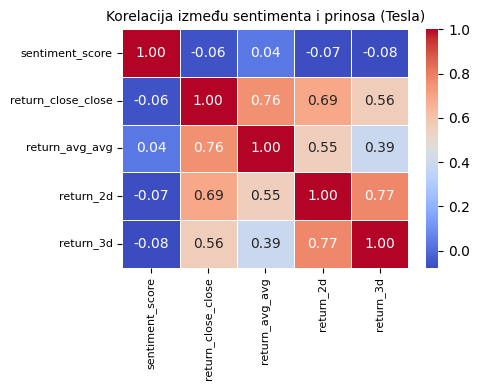

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Korelacija između sentimenta i prinosa (Tesla)", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()



plt.show()

In [46]:
tsla_final.to_csv("/content/drive/MyDrive/tsla_final.csv", index=False)